# Bootstrap Test: Alt Mean > 50

One-sided bootstrap test for whether the alt distribution mean exceeds 50.

Per-dataset, pooling across the 5 perturbation types (excluding noperturb). P-value uses the Phipson & Smyth correction.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

BASE_DIR = Path("..").resolve()
CSV_PATH = BASE_DIR / "aggregated_results" / "aggregated_results.csv"
N_BOOT = 10_000

In [3]:
if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"Expected aggregated results at {CSV_PATH}. "
        "Run scripts/aggregate_conclusions.py first."
    )

df = pd.read_csv(CSV_PATH, keep_default_na=False)

# Keep only alt distribution, exclude the "none" perturbation
alt_df = df[(df["distribution"] == "alt") & (df["perturbation"] != "none")].copy()
datasets = sorted(alt_df["dataset"].unique())

print(f"{len(alt_df)} alt rows (excl. none), {len(datasets)} datasets")
print(f"Perturbations: {sorted(alt_df['perturbation'].unique())}")
print(f"Rows per dataset:\n{alt_df.groupby('dataset').size().to_string()}")

1100 alt rows (excl. none), 11 datasets
Perturbations: ['add_features', 'anonymize', 'negative_leading_statement', 'positive_leading_statement', 'shuffle_names']
Rows per dataset:
dataset
affairs            100
amtl               100
boxes              100
caschools          100
crofoot            100
hurricane          100
mortgage           100
panda_nuts         100
reading            100
soccer             100
teachingratings    100


In [4]:
def bootstrap_mean_test(
    x: np.ndarray,
    mu0: float = 50.0,
    n_boot: int = N_BOOT,
    rng: np.random.Generator | None = None,
) -> tuple[float, float, np.ndarray, tuple[float, float]]:
    """One-sided bootstrap test for H1: mean(x) > mu0.

    Returns (observed_mean, p_value, boot_means, ci_95).
    """
    if rng is None:
        rng = np.random.default_rng()

    obs_mean = float(np.mean(x))
    n = len(x)

    # resample with replacement
    idx = rng.integers(0, n, size=(n_boot, n))
    boot_means = np.mean(x[idx], axis=1)

    # one-sided p-value: proportion of bootstrap means <= mu0
    p_value = ((boot_means <= mu0).sum() + 1) / (n_boot + 1)

    ci_95 = (float(np.percentile(boot_means, 2.5)), float(np.percentile(boot_means, 97.5)))
    return obs_mean, p_value, boot_means, ci_95

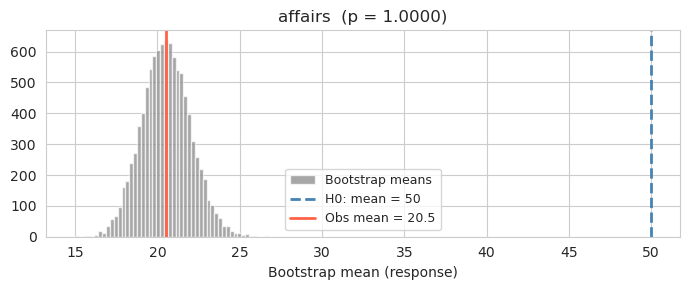

affairs: n=100  mean=20.53  95% CI=[17.70, 23.49]  p=1.0000


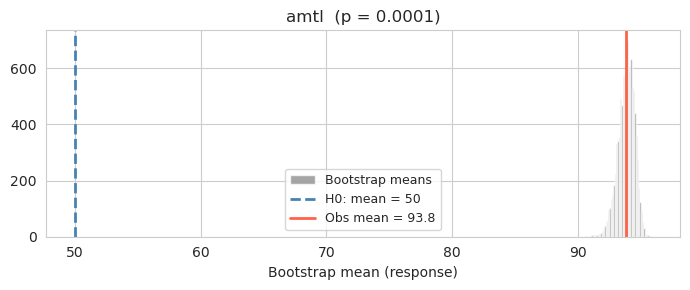

amtl: n=100  mean=93.85  95% CI=[92.42, 94.97]  p=0.0001


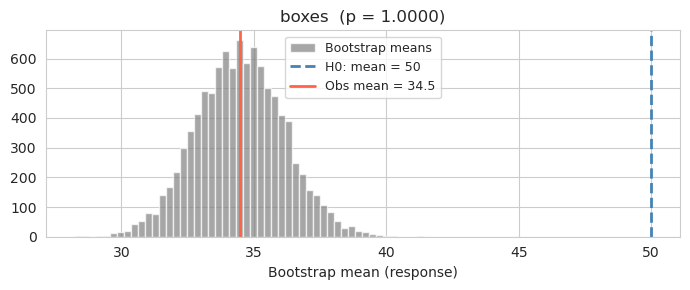

boxes: n=100  mean=34.46  95% CI=[31.25, 37.77]  p=1.0000


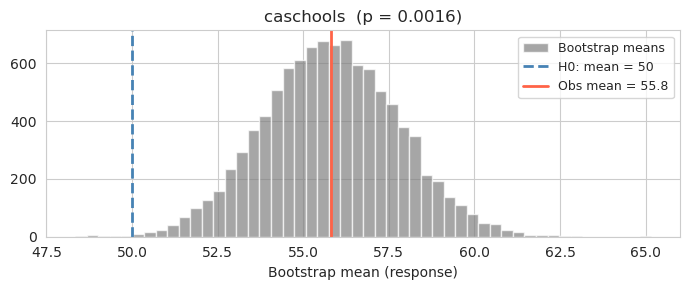

caschools: n=100  mean=55.81  95% CI=[51.98, 59.73]  p=0.0016


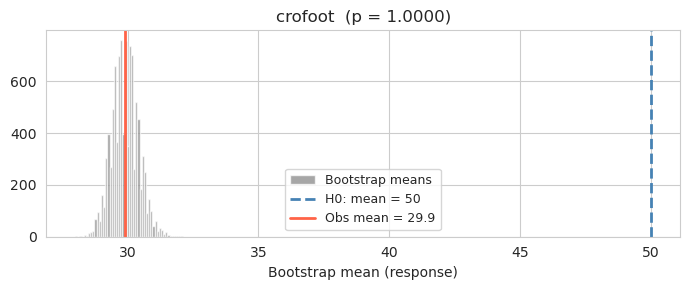

crofoot: n=100  mean=29.90  95% CI=[28.95, 30.95]  p=1.0000


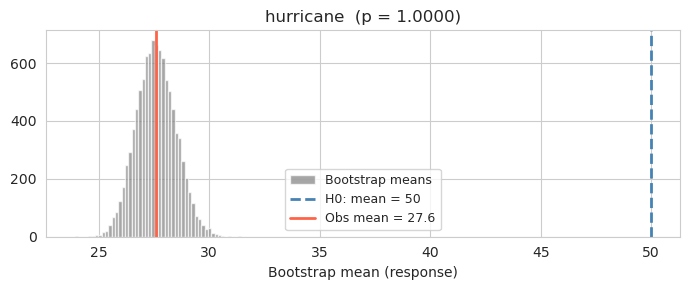

hurricane: n=100  mean=27.58  95% CI=[25.90, 29.35]  p=1.0000


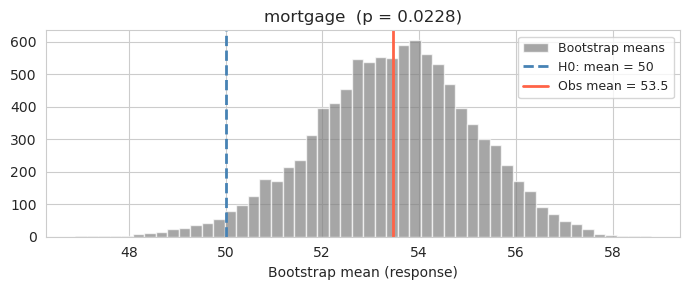

mortgage: n=100  mean=53.46  95% CI=[50.07, 56.50]  p=0.0228


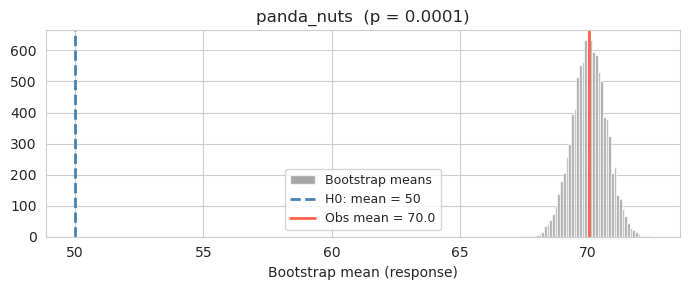

panda_nuts: n=100  mean=70.04  95% CI=[68.71, 71.36]  p=0.0001


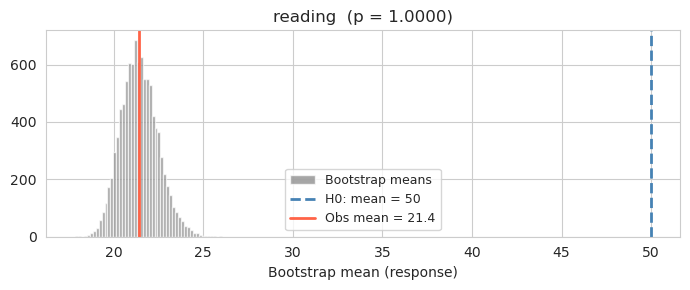

reading: n=100  mean=21.43  95% CI=[19.53, 23.61]  p=1.0000


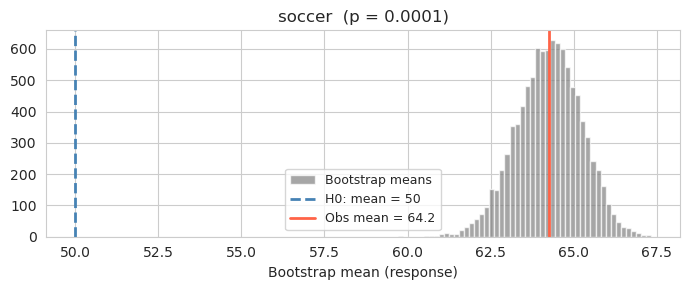

soccer: n=100  mean=64.25  95% CI=[62.26, 66.06]  p=0.0001


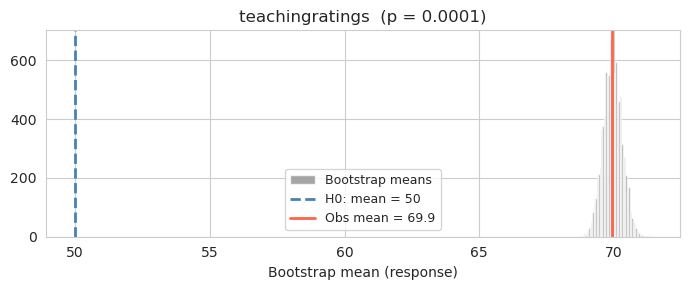

teachingratings: n=100  mean=69.94  95% CI=[69.26, 70.63]  p=0.0001


In [5]:
rng = np.random.default_rng(42)
results = []

for dataset_name in datasets:
    vals = alt_df.loc[alt_df["dataset"] == dataset_name, "response"].values.astype(float)
    obs_mean, p_val, boot_means, ci = bootstrap_mean_test(vals, rng=rng)

    results.append({
        "dataset": dataset_name,
        "n": len(vals),
        "obs_mean": obs_mean,
        "ci_lo": ci[0],
        "ci_hi": ci[1],
        "p_value": p_val,
    })

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.hist(boot_means, bins=50, color="gray", alpha=0.7, label="Bootstrap means")
    ax.axvline(50, color="steelblue", linewidth=2, linestyle="--", label="H0: mean = 50")
    ax.axvline(obs_mean, color="tomato", linewidth=2, label=f"Obs mean = {obs_mean:.1f}")
    ax.set_xlabel("Bootstrap mean (response)")
    ax.set_title(f"{dataset_name}  (p = {p_val:.4f})")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    print(f"{dataset_name}: n={len(vals)}  mean={obs_mean:.2f}  95% CI=[{ci[0]:.2f}, {ci[1]:.2f}]  p={p_val:.4f}")

## Summary

In [6]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

        dataset   n  obs_mean    ci_lo    ci_hi  p_value
        affairs 100     20.53 17.70000 23.49000 1.000000
           amtl 100     93.85 92.41975 94.97000 0.000100
          boxes 100     34.46 31.24975 37.77000 1.000000
      caschools 100     55.81 51.98000 59.73000 0.001600
        crofoot 100     29.90 28.95000 30.95000 1.000000
      hurricane 100     27.58 25.89975 29.35025 1.000000
       mortgage 100     53.46 50.06975 56.50000 0.022798
     panda_nuts 100     70.04 68.71000 71.36000 0.000100
        reading 100     21.43 19.53000 23.61025 1.000000
         soccer 100     64.25 62.26000 66.06000 0.000100
teachingratings 100     69.94 69.26000 70.63000 0.000100


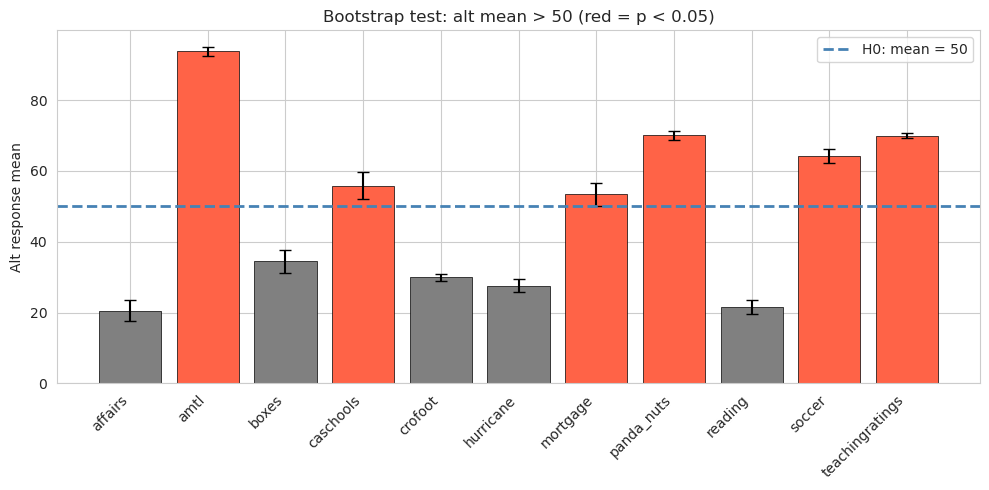

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = np.arange(len(results_df))
means = results_df["obs_mean"].values
ci_lo = results_df["ci_lo"].values
ci_hi = results_df["ci_hi"].values
err_lo = means - ci_lo
err_hi = ci_hi - means

colors = ["tomato" if p < 0.05 else "gray" for p in results_df["p_value"]]
ax.bar(x_pos, means, yerr=[err_lo, err_hi], capsize=4, color=colors, edgecolor="black", linewidth=0.5)
ax.axhline(50, color="steelblue", linewidth=2, linestyle="--", label="H0: mean = 50")
ax.set_xticks(x_pos)
ax.set_xticklabels(results_df["dataset"], rotation=45, ha="right")
ax.set_ylabel("Alt response mean")
ax.set_title("Bootstrap test: alt mean > 50 (red = p < 0.05)")
ax.legend()
plt.tight_layout()
plt.show()

# Proportion Test: P(response > 50) > 0.5

The mean test can be misleading when a distribution has heavy mass on both sides of 50.
This test asks whether the model consistently answers above 50, not just on average.

One-sided exact binomial test for $H_1: p > 0.5$ where $p = P(X > 50)$.
Responses exactly equal to 50 are excluded (neither yes nor no).

In [8]:
from scipy.stats import binomtest

prop_results = []

for dataset_name in datasets:
    vals = alt_df.loc[alt_df["dataset"] == dataset_name, "response"].values.astype(float)
    above = (vals > 50).sum()
    below = (vals < 50).sum()
    n_valid = above + below  # exclude exact 50s

    prop_above = above / n_valid if n_valid > 0 else np.nan
    bt = binomtest(above, n_valid, 0.5, alternative="greater")

    prop_results.append({
        "dataset": dataset_name,
        "n": len(vals),
        "n_above": int(above),
        "n_below": int(below),
        "n_eq50": int((vals == 50).sum()),
        "prop_above": prop_above,
        "p_value": bt.pvalue,
    })

    print(f"{dataset_name}: {above}/{n_valid} above 50 ({prop_above:.2%})  p={bt.pvalue:.4f}")

prop_df = pd.DataFrame(prop_results)

affairs: 2/98 above 50 (2.04%)  p=1.0000
amtl: 99/100 above 50 (99.00%)  p=0.0000
boxes: 20/97 above 50 (20.62%)  p=1.0000
caschools: 57/100 above 50 (57.00%)  p=0.0967
crofoot: 1/100 above 50 (1.00%)  p=1.0000
hurricane: 3/100 above 50 (3.00%)  p=1.0000
mortgage: 83/100 above 50 (83.00%)  p=0.0000
panda_nuts: 99/100 above 50 (99.00%)  p=0.0000
reading: 4/100 above 50 (4.00%)  p=1.0000
soccer: 86/100 above 50 (86.00%)  p=0.0000
teachingratings: 100/100 above 50 (100.00%)  p=0.0000


## Proportion Summary

In [9]:
print(prop_df.to_string(index=False))

        dataset   n  n_above  n_below  n_eq50  prop_above      p_value
        affairs 100        2       96       2    0.020408 1.000000e+00
           amtl 100       99        1       0    0.990000 7.967495e-29
          boxes 100       20       77       3    0.206186 1.000000e+00
      caschools 100       57       43       0    0.570000 9.667395e-02
        crofoot 100        1       99       0    0.010000 1.000000e+00
      hurricane 100        3       97       0    0.030000 1.000000e+00
       mortgage 100       83       17       0    0.830000 6.548999e-12
     panda_nuts 100       99        1       0    0.990000 7.967495e-29
        reading 100        4       96       0    0.040000 1.000000e+00
         soccer 100       86       14       0    0.860000 4.142226e-14
teachingratings 100      100        0       0    1.000000 7.888609e-31


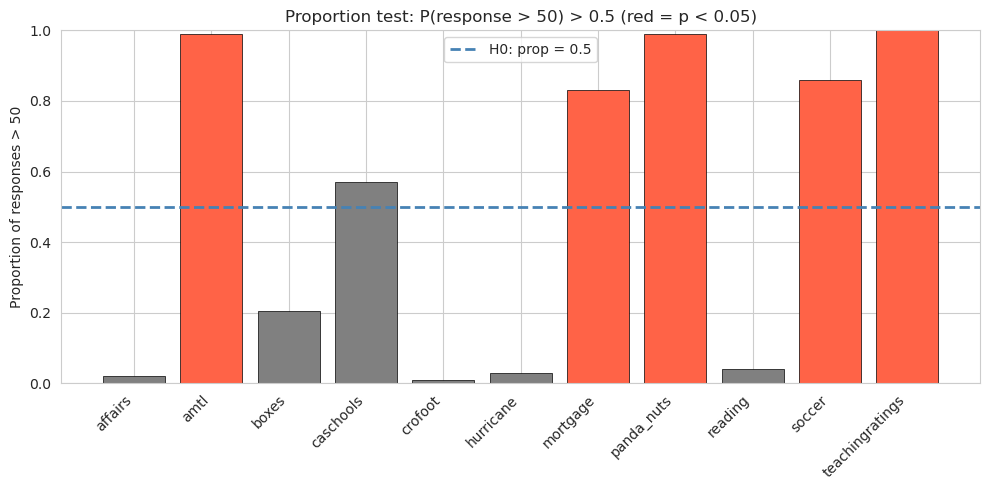

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = np.arange(len(prop_df))
props = prop_df["prop_above"].values
colors = ["tomato" if p < 0.05 else "gray" for p in prop_df["p_value"]]

ax.bar(x_pos, props, color=colors, edgecolor="black", linewidth=0.5)
ax.axhline(0.5, color="steelblue", linewidth=2, linestyle="--", label="H0: prop = 0.5")
ax.set_xticks(x_pos)
ax.set_xticklabels(prop_df["dataset"], rotation=45, ha="right")
ax.set_ylabel("Proportion of responses > 50")
ax.set_title("Proportion test: P(response > 50) > 0.5 (red = p < 0.05)")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

# Overlap Coefficient: Alt vs Null

Measures how much the alt and null response distributions overlap using Gaussian KDE.

Excludes `perturbation == "none"` from both distributions.

In [11]:
from scipy import stats

X_GRID = np.linspace(0, 100, 1000)


def overlap_coefficient(
    a: np.ndarray, b: np.ndarray, x_grid: np.ndarray = X_GRID, bw: float | None = None
) -> float:
    """Area of overlap between two KDE-estimated distributions (0 to 1).

    If bw is None, uses Scott's rule (scipy default). Otherwise uses the given
    fixed bandwidth for both KDEs.
    """
    kde_a = stats.gaussian_kde(a)
    kde_b = stats.gaussian_kde(b)
    if bw is not None:
        kde_a.set_bandwidth(bw_method=bw / kde_a.dataset.std(ddof=1))
        kde_b.set_bandwidth(bw_method=bw / kde_b.dataset.std(ddof=1))
    return float(np.trapz(np.minimum(kde_a(x_grid), kde_b(x_grid)), x_grid))

/tmp/ipykernel_3351619/266673901.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(np.minimum(kde_a(x_grid), kde_b(x_grid)), x_grid))


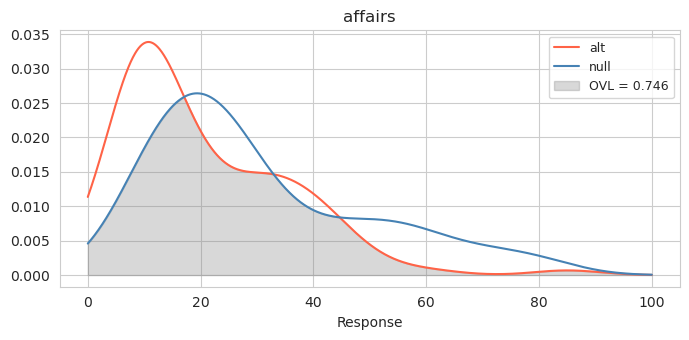

affairs: OVL=0.7459


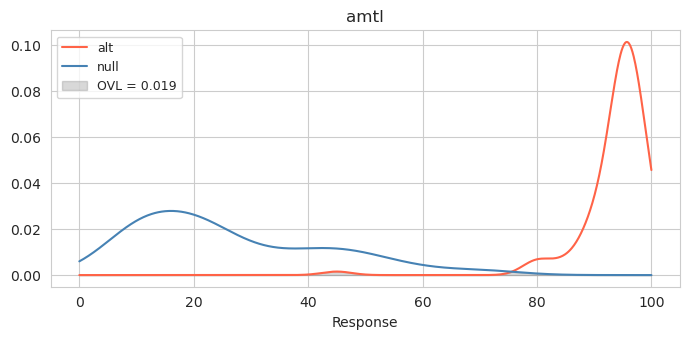

amtl: OVL=0.0189


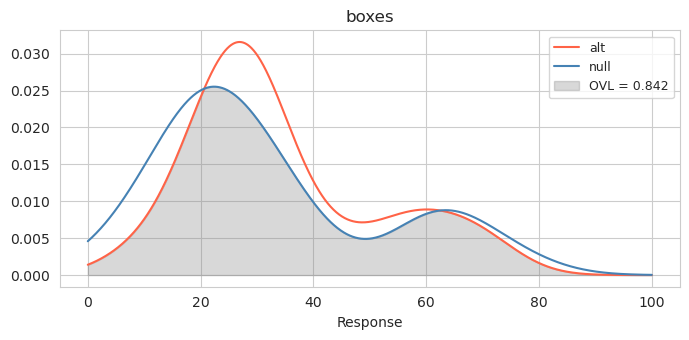

boxes: OVL=0.8422


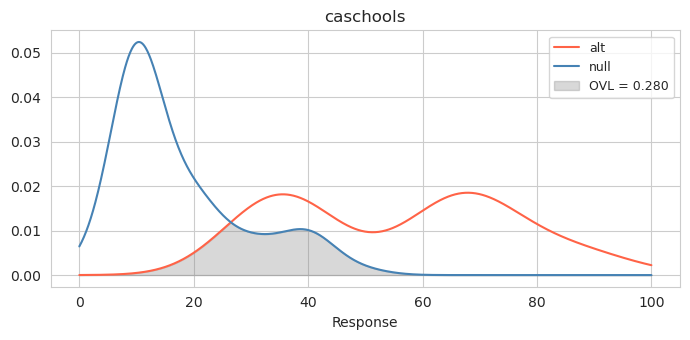

caschools: OVL=0.2799


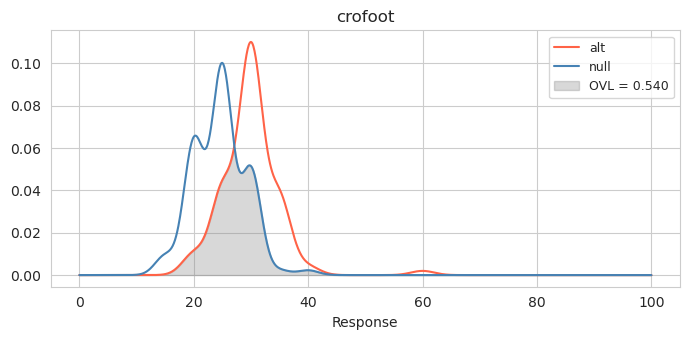

crofoot: OVL=0.5403


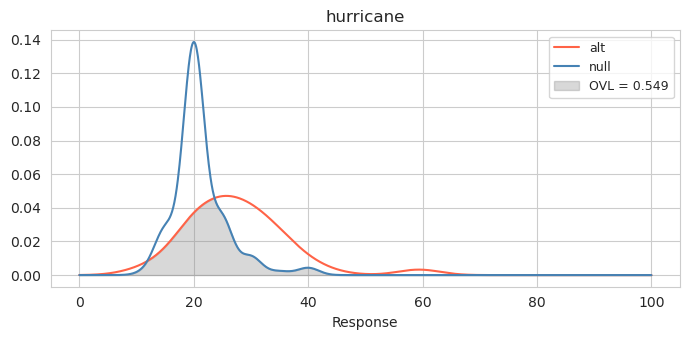

hurricane: OVL=0.5493


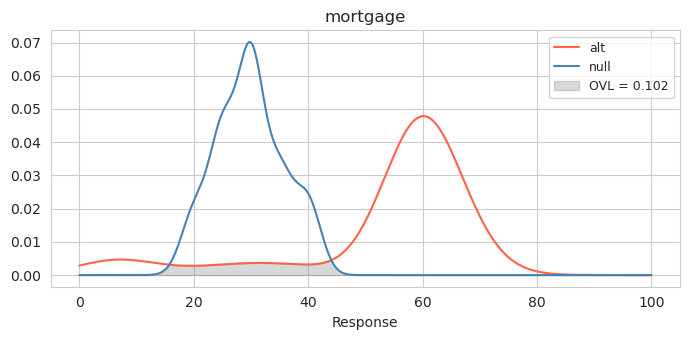

mortgage: OVL=0.1015


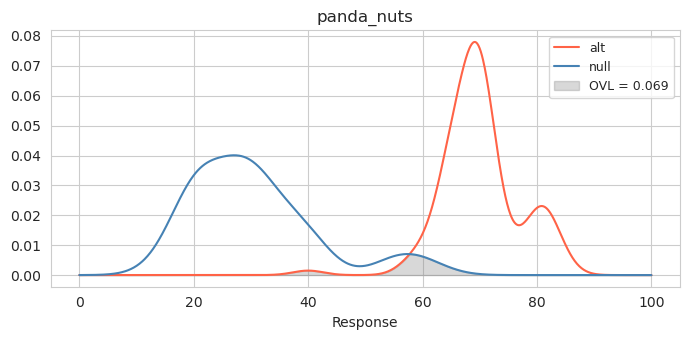

panda_nuts: OVL=0.0688


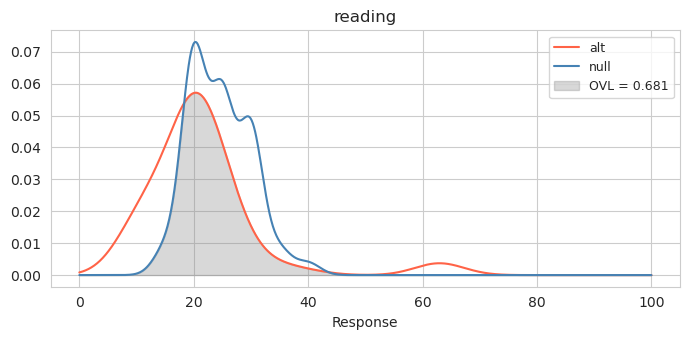

reading: OVL=0.6805


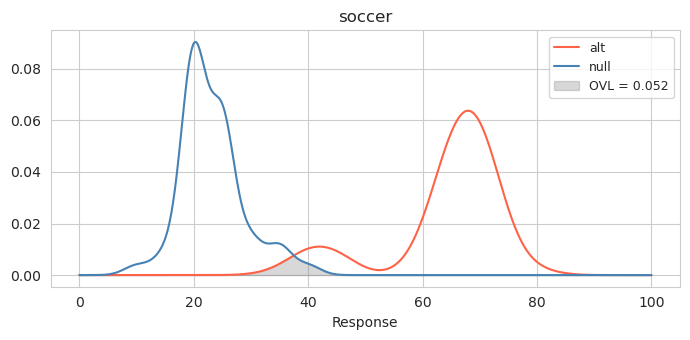

soccer: OVL=0.0523


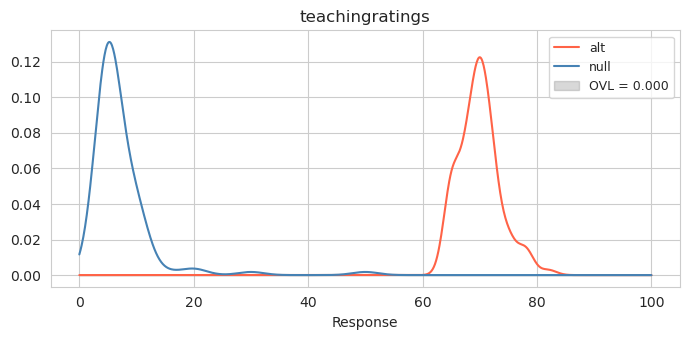

teachingratings: OVL=0.0000


In [12]:
# Filter both alt and null, excluding "none" perturbation
perturbed_df = df[df["perturbation"] != "none"].copy()

ovl_results = []

for dataset_name in datasets:
    sub = perturbed_df[perturbed_df["dataset"] == dataset_name]
    alt_vals = sub.loc[sub["distribution"] == "alt", "response"].values.astype(float)
    null_vals = sub.loc[sub["distribution"] == "null", "response"].values.astype(float)

    ovl = overlap_coefficient(alt_vals, null_vals)

    ovl_results.append({
        "dataset": dataset_name,
        "n_alt": len(alt_vals),
        "n_null": len(null_vals),
        "ovl": ovl,
    })

    # KDE + overlap shading
    kde_alt = stats.gaussian_kde(alt_vals)
    kde_null = stats.gaussian_kde(null_vals)
    y_alt = kde_alt(X_GRID)
    y_null = kde_null(X_GRID)

    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(X_GRID, y_alt, color="tomato", label="alt")
    ax.plot(X_GRID, y_null, color="steelblue", label="null")
    ax.fill_between(X_GRID, np.minimum(y_alt, y_null), alpha=0.3, color="gray", label=f"OVL = {ovl:.3f}")
    ax.set_xlabel("Response")
    ax.set_title(f"{dataset_name}")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    print(f"{dataset_name}: OVL={ovl:.4f}")

ovl_df = pd.DataFrame(ovl_results)

## Overlap Summary

In [13]:
print(ovl_df.to_string(index=False))

        dataset  n_alt  n_null      ovl
        affairs    100     100 0.745854
           amtl    100     100 0.018919
          boxes    100     100 0.842178
      caschools    100     100 0.279889
        crofoot    100     100 0.540292
      hurricane    100     100 0.549272
       mortgage    100     100 0.101540
     panda_nuts    100     100 0.068848
        reading    100     100 0.680515
         soccer    100     100 0.052316
teachingratings    100     100 0.000001


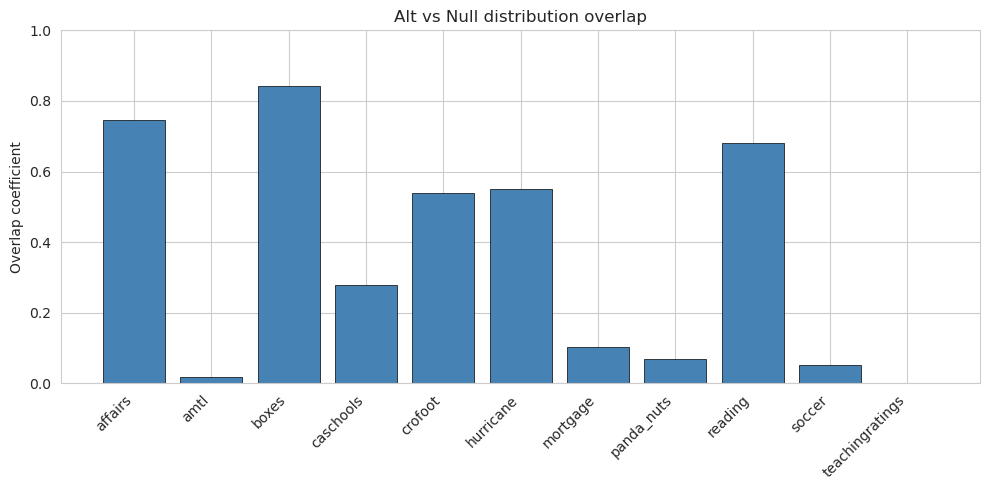

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = np.arange(len(ovl_df))
ovls = ovl_df["ovl"].values

ax.bar(x_pos, ovls, color="steelblue", edgecolor="black", linewidth=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(ovl_df["dataset"], rotation=45, ha="right")
ax.set_ylabel("Overlap coefficient")
ax.set_ylim(0, 1)
ax.set_title("Alt vs Null distribution overlap")
plt.tight_layout()
plt.show()

## Bandwidth Sensitivity

The default OVL above uses Scott's rule, which picks a different bandwidth per distribution
based on its standard deviation. Below we compare the default against several fixed bandwidths
applied uniformly across all datasets.

In [15]:
fixed_bws = [3, 5, 8, 12]

# collect OVL for each bandwidth setting
bw_comparison = {}
bw_comparison["scott"] = ovl_df.set_index("dataset")["ovl"]

for bw in fixed_bws:
    ovls = {}
    for dataset_name in datasets:
        sub = perturbed_df[perturbed_df["dataset"] == dataset_name]
        alt_vals = sub.loc[sub["distribution"] == "alt", "response"].values.astype(float)
        null_vals = sub.loc[sub["distribution"] == "null", "response"].values.astype(float)
        ovls[dataset_name] = overlap_coefficient(alt_vals, null_vals, bw=bw)
    bw_comparison[f"bw={bw}"] = pd.Series(ovls)

bw_df = pd.DataFrame(bw_comparison)
print(bw_df.to_string(float_format="%.3f"))

/tmp/ipykernel_3351619/266673901.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(np.minimum(kde_a(x_grid), kde_b(x_grid)), x_grid))


                 scott  bw=3  bw=5  bw=8  bw=12
affairs          0.746 0.655 0.713 0.773  0.779
amtl             0.019 0.014 0.023 0.036  0.064
boxes            0.842 0.783 0.821 0.854  0.870
caschools        0.280 0.228 0.255 0.301  0.355
crofoot          0.540 0.603 0.688 0.772  0.827
hurricane        0.549 0.596 0.671 0.747  0.790
mortgage         0.102 0.095 0.125 0.215  0.346
panda_nuts       0.069 0.070 0.087 0.114  0.186
reading          0.681 0.705 0.736 0.787  0.822
soccer           0.052 0.051 0.071 0.103  0.163
teachingratings  0.000 0.000 0.004 0.009  0.022


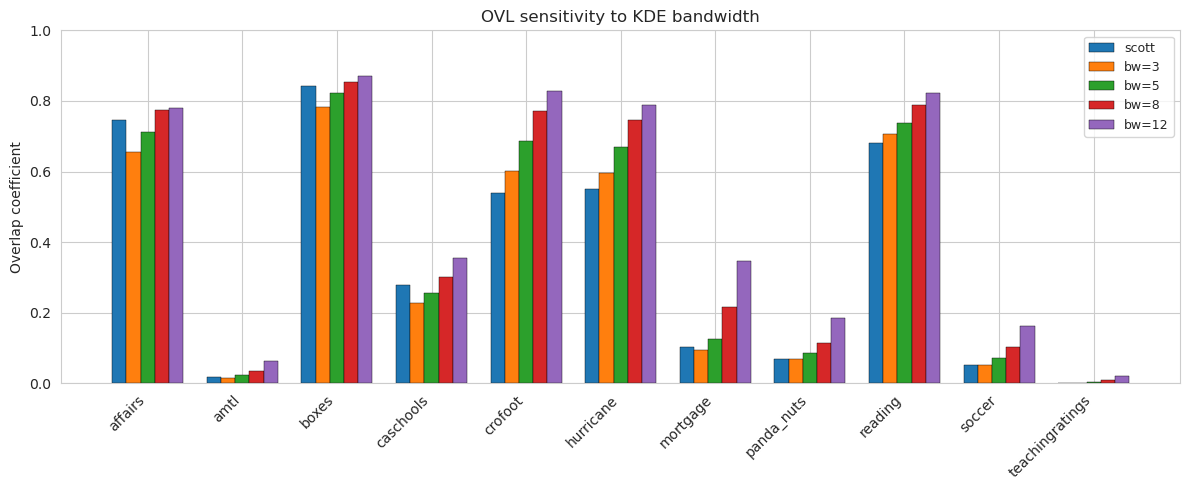

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))

x_pos = np.arange(len(datasets))
width = 0.15
labels = list(bw_df.columns)

for i, col in enumerate(labels):
    offset = (i - len(labels) / 2 + 0.5) * width
    ax.bar(x_pos + offset, bw_df[col].values, width, label=col, edgecolor="black", linewidth=0.3)

ax.set_xticks(x_pos)
ax.set_xticklabels(datasets, rotation=45, ha="right")
ax.set_ylabel("Overlap coefficient")
ax.set_ylim(0, 1)
ax.set_title("OVL sensitivity to KDE bandwidth")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Dataset Classification

Combining the proportion test and overlap coefficient (bw=5) into a 2x2 classification.

- Prop. test: is P(response > 50) > 0.5 significant at $\alpha = 0.05$?
- Overlap score: is the alt-vs-null OVL below a threshold?

Together these give four categories:
| | Low overlap | High overlap |
|---|---|---|
| Prop. sig. | Confident Yes: model consistently says yes, and alt/null are well separated | Analysis Failure: model says yes, but alt/null look similar |
| Prop. not sig. | Low Signal: model doesn't say yes, yet alt/null differ | No Signal: model doesn't say yes, and alt/null overlap |

In [19]:
OVL_BW = 5
OVL_THRESHOLD = 0.3 
PROP_ALPHA = 0.05

# recompute OVL with fixed bandwidth
ovl_fixed = {}
for dataset_name in datasets:
    sub = perturbed_df[perturbed_df["dataset"] == dataset_name]
    alt_vals = sub.loc[sub["distribution"] == "alt", "response"].values.astype(float)
    null_vals = sub.loc[sub["distribution"] == "null", "response"].values.astype(float)
    ovl_fixed[dataset_name] = overlap_coefficient(alt_vals, null_vals, bw=OVL_BW)

# build combined table
combined = prop_df[["dataset", "prop_above", "p_value"]].copy()
combined = combined.rename(columns={"p_value": "prop_pvalue"})
combined["ovl"] = combined["dataset"].map(ovl_fixed)
combined["prop_sig"] = combined["prop_pvalue"] < PROP_ALPHA
combined["low_ovl"] = combined["ovl"] < OVL_THRESHOLD

def classify(row):
    if row["prop_sig"] and row["low_ovl"]:
        return "Confident Yes"
    elif row["prop_sig"] and not row["low_ovl"]:
        return "Low Signal"
    elif not row["prop_sig"] and row["low_ovl"]:
        return "Analysis Failure"
    else:
        return "No Signal"

combined["category"] = combined.apply(classify, axis=1)

print(f"OVL bandwidth: {OVL_BW},  OVL threshold: {OVL_THRESHOLD},  alpha: {PROP_ALPHA}\n")
print(combined[["dataset", "prop_above", "prop_pvalue", "ovl", "category"]].to_string(index=False))

OVL bandwidth: 5,  OVL threshold: 0.3,  alpha: 0.05

        dataset  prop_above  prop_pvalue      ovl         category
        affairs    0.020408 1.000000e+00 0.712880        No Signal
           amtl    0.990000 7.967495e-29 0.022866    Confident Yes
          boxes    0.206186 1.000000e+00 0.821429        No Signal
      caschools    0.570000 9.667395e-02 0.255084 Analysis Failure
        crofoot    0.010000 1.000000e+00 0.687631        No Signal
      hurricane    0.030000 1.000000e+00 0.670853        No Signal
       mortgage    0.830000 6.548999e-12 0.125128    Confident Yes
     panda_nuts    0.990000 7.967495e-29 0.087207    Confident Yes
        reading    0.040000 1.000000e+00 0.736268        No Signal
         soccer    0.860000 4.142226e-14 0.071168    Confident Yes
teachingratings    1.000000 7.888609e-31 0.004436    Confident Yes


/tmp/ipykernel_3351619/266673901.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(np.minimum(kde_a(x_grid), kde_b(x_grid)), x_grid))


Confident Yes: ['amtl', 'mortgage', 'panda_nuts', 'soccer', 'teachingratings']
Low Signal: (none)
Analysis Failure: ['caschools']
No Signal: ['affairs', 'boxes', 'crofoot', 'hurricane', 'reading']


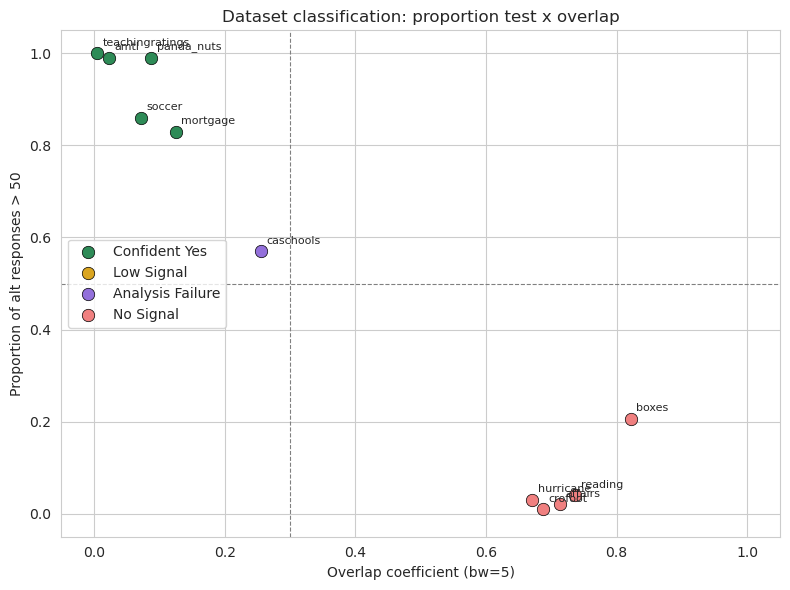

In [21]:
categories = ["Confident Yes", "Low Signal", "Analysis Failure", "No Signal"]
cat_colors = {"Confident Yes": "seagreen", "Low Signal": "goldenrod", "Analysis Failure": "mediumpurple", "No Signal": "lightcoral"}

for cat in categories:
    members = combined.loc[combined["category"] == cat, "dataset"].tolist()
    print(f"{cat}: {members if members else '(none)'}")

# scatter: proportion above 50 vs OVL, colored by category
fig, ax = plt.subplots(figsize=(8, 6))

for cat in categories:
    mask = combined["category"] == cat
    sub = combined[mask]
    ax.scatter(sub["ovl"], sub["prop_above"], color=cat_colors[cat], s=80, label=cat, edgecolor="black", linewidth=0.5)
    for _, row in sub.iterrows():
        ax.annotate(row["dataset"], (row["ovl"], row["prop_above"]),
                     fontsize=8, ha="left", va="bottom", xytext=(4, 4), textcoords="offset points")

ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(OVL_THRESHOLD, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel(f"Overlap coefficient (bw={OVL_BW})")
ax.set_ylabel("Proportion of alt responses > 50")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_title("Dataset classification: proportion test x overlap")
ax.legend(loc="center left")
plt.tight_layout()
plt.show()